# Weakly Supervised Multi-Class Retinal Disease Classification  
## with Attention-Guided EfficientNetV2 and Grad-CAM Explainability

**Phase 2: Disease Localization & Explainable AI**

This notebook presents a complete weakly supervised deep learning pipeline for:
- Multi-class retinal disease classification
- Attention-guided lesion localization
- Explainability using Grad-CAM

The system is trained using only image-level labels (no pixel-level annotations) on a fundus image dataset containing both original and augmented samples.


## 🎯 Project Objective

The primary objective of this work is to develop a **weakly supervised deep learning framework** that can:

1. Accurately classify retinal fundus images into **10 disease categories**
2. Localize disease-specific lesion regions **without pixel-level masks**
3. Provide visual explainability using **attention maps and Grad-CAM**
4. Enable reuse of the trained model without retraining

This approach aims to assist ophthalmologists by improving **model interpretability and clinical trust**.


In [9]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm


## Global Configuration and Hyperparameters

This cell defines all global parameters used across the notebook:

- Input image size
- Batch size
- Number of disease classes
- Number of training epochs
- Device selection (GPU if available)

Centralizing these values makes the notebook easier to modify and maintain.


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 10
EPOCHS = 15
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Image Preprocessing and Data Augmentation

This cell defines preprocessing pipelines for:

### Training:
- Random horizontal flipping
- Random rotation
- Color jittering
- Normalization (ImageNet statistics)

### Validation / Inference:
- Only resizing and normalization
- No randomness to ensure consistent predictions

Data augmentation improves generalization and robustness of the model.


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

original_dataset = datasets.ImageFolder("/kaggle/input/eye-disease-image-dataset/data/Original_Dataset", transform=train_transform)
augmented_dataset = datasets.ImageFolder("/kaggle/input/eye-disease-image-dataset/data/Augmented_Dataset", transform=train_transform)

# Merge both datasets
full_dataset = ConcatDataset([original_dataset, augmented_dataset])

train_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True)

class_names = original_dataset.classes
print("Classes:", class_names)


Classes: ['Central Serous Chorioretinopathy', 'Diabetic Retinopathy', 'Disc Edema', 'Glaucoma', 'Healthy', 'Macular Scar', 'Myopia', 'Pterygium', 'Retinal Detachment', 'Retinitis Pigmentosa']


## 📂 Dataset Description

The dataset consists of retinal fundus images organized into two subsets:

- **Original Dataset**
- **Augmented Dataset**

Each subset contains images from **10 retinal disease categories**:

1. Central Serous Chorioretinopathy  
2. Diabetic Retinopathy  
3. Disc Edema  
4. Glaucoma  
5. Healthy  
6. Macular Scar  
7. Myopia  
8. Pterygium  
9. Retinal Detachment  
10. Retinitis Pigmentosa  

Only **image-level labels** are available.  
No lesion masks or bounding boxes are provided, making this a **weakly supervised learning problem**.


In [6]:
class EfficientNetAttention(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        backbone = models.efficientnet_v2_s(pretrained=True)
        self.features = backbone.features

        self.attention = nn.Sequential(
            nn.Conv2d(1280, 256, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(256, 1, kernel_size=1),
            nn.Sigmoid()
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        feat = self.features(x)          # (B,1280,H,W)
        attn = self.attention(feat)      # (B,1,H,W)
        feat = feat * attn               # weak lesion localization
        pooled = self.pool(feat).flatten(1)
        out = self.classifier(pooled)
        return out, attn


## Model Architecture: EfficientNetV2 with Attention Mechanism

This cell defines the core deep learning model.

### Architecture Overview:
1. EfficientNetV2-S backbone for feature extraction
2. Attention module to highlight disease-relevant regions
3. Global Average Pooling
4. Fully connected classification layer

The attention map acts as a weak lesion localization mechanism,
allowing spatial interpretability without pixel-level supervision.

## Model Initialization and Optimization Setup

This cell:
- Instantiates the EfficientNetV2 attention model
- Moves it to the selected device (CPU/GPU)
- Defines the loss function (Cross-Entropy)
- Configures the AdamW optimizer

AdamW is chosen for better regularization and stable convergence.

## Model Training Loop

This cell performs model training over multiple epochs.

Key points:
- Uses image-level labels only
- Computes classification loss
- Updates model parameters via backpropagation
- Displays real-time batch loss using `tqdm`

The attention mechanism learns implicitly during classification training.


In [10]:
model = EfficientNetAttention(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    # tqdm wraps the dataloader
    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch+1}/{EPOCHS}]",
        leave=True
    )

    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs, _ = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # update progress bar with current batch loss
        progress_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}",
            avg_loss=f"{total_loss / (progress_bar.n + 1):.4f}"
        )

    epoch_loss = total_loss / len(train_loader)
    print(f"✅ Epoch [{epoch+1}/{EPOCHS}] Completed | Avg Loss: {epoch_loss:.4f}\n")


Epoch [1/15]: 100%|██████████| 1349/1349 [17:31<00:00,  1.28it/s, avg_loss=0.6752, batch_loss=0.4973]


✅ Epoch [1/15] Completed | Avg Loss: 0.6752



Epoch [2/15]: 100%|██████████| 1349/1349 [17:34<00:00,  1.28it/s, avg_loss=0.3942, batch_loss=0.3732]


✅ Epoch [2/15] Completed | Avg Loss: 0.3942



Epoch [3/15]: 100%|██████████| 1349/1349 [17:44<00:00,  1.27it/s, avg_loss=0.3162, batch_loss=0.1237]


...

✅ Epoch [13/15] Completed | Avg Loss: 0.1734



Epoch [14/15]: 100%|██████████| 1349/1349 [19:24<00:00,  1.16it/s, avg_loss=0.1718, batch_loss=0.1659]


✅ Epoch [14/15] Completed | Avg Loss: 0.1718



Epoch [15/15]: 100%|██████████| 1349/1349 [19:16<00:00,  1.17it/s, avg_loss=0.1686, batch_loss=0.3068]

✅ Epoch [15/15] Completed | Avg Loss: 0.1686



## Model Evaluation and Performance Metrics

This cell evaluates the trained model and computes:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Metrics are calculated using `sklearn` utilities.
This evaluation provides insight into class-wise performance.

Note: For rigorous validation, a separate test set is recommended.


In [12]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

model.eval()
y_true, y_pred = [], []
running_correct = 0
total_samples = 0

progress_bar = tqdm(
    train_loader,
    desc="Evaluating",
    leave=True
)

with torch.no_grad():
    for imgs, labels in progress_bar:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs, _ = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        # running accuracy update
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        current_acc = running_correct / total_samples

        progress_bar.set_postfix(
            acc=f"{current_acc:.4f}"
        )

# Final metrics
print("\n✅ Final Evaluation Results")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n",
      classification_report(y_true, y_pred, target_names=class_names))
print("\nConfusion Matrix:\n",
      confusion_matrix(y_true, y_pred))


Evaluating: 100%|██████████| 1349/1349 [15:31<00:00,  1.45it/s, acc=0.9291]


✅ Final Evaluation Results
Accuracy: 0.9291375075311674

Classification Report:
                                   precision    recall  f1-score   support

Central Serous Chorioretinopathy       0.89      0.94      0.92       707
            Diabetic Retinopathy       0.97      0.98      0.98      4953
                      Disc Edema       0.96      0.99      0.97       889
                        Glaucoma       0.87      0.89      0.88      4229
                         Healthy       0.96      0.88      0.92      3700
                    Macular Scar       0.94      0.87      0.90      2381
                          Myopia       0.88      0.95      0.91      2751
                       Pterygium       1.00      1.00      1.00       119
              Retinal Detachment       0.98      1.00      0.99       875
            Retinitis Pigmentosa       0.94      0.99      0.96       973

                        accuracy                           0.93     21577
                       macro

## Attention Map Visualization (Weak Lesion Segmentation)

This cell defines a helper function to visualize attention maps.

The attention map:
- Is resized to input image resolution
- Converted into a heatmap
- Overlaid on the original fundus image

This provides a coarse but interpretable localization of lesions.


In [13]:
def get_attention_overlay(img, attn_map):
    heatmap = attn_map.squeeze().cpu().numpy()
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img = img.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    overlay = heatmap * 0.4 + img * 255
    return overlay.astype(np.uint8)


## Grad-CAM Heatmap Generation

This cell defines a function to generate Grad-CAM heatmaps
for a specific predicted class.

The final convolutional layer of EfficientNetV2
is used as the target layer for gradient backpropagation.


In [18]:
!pip install grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer = model.features[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

def generate_gradcam(img, class_id):
    grayscale_cam = cam(
        input_tensor=img.unsqueeze(0),
        targets=[ClassifierOutputTarget(class_id)]
    )
    return grayscale_cam[0]


## Sample Prediction and Visualization

This cell:
- Selects a sample image from the dataset
- Performs disease prediction
- Generates attention-based lesion localization
- Generates Grad-CAM explainability

The results are visualized side-by-side for interpretability.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].


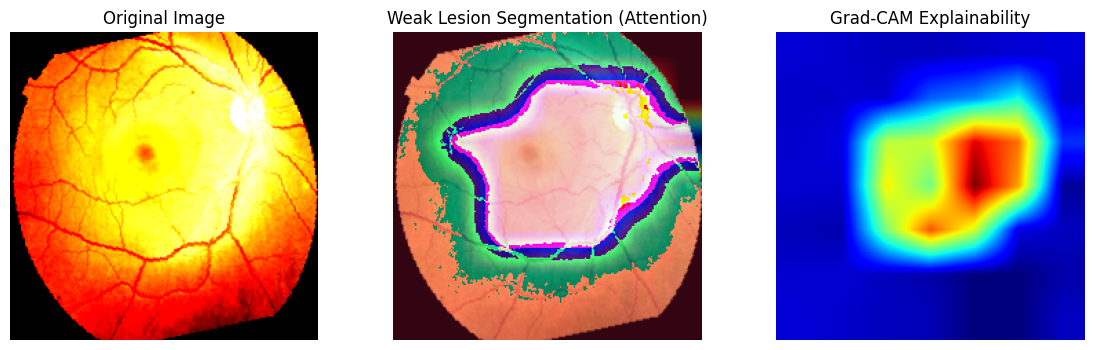

In [19]:
img, label = original_dataset[0]
img = img.to(DEVICE)

model.eval()
with torch.no_grad():
    out, attn = model(img.unsqueeze(0))
    pred = torch.argmax(out, dim=1).item()

attn_overlay = get_attention_overlay(img.cpu(), attn)
gradcam_map = generate_gradcam(img, pred)

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img.cpu().permute(1,2,0))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Weak Lesion Segmentation (Attention)")
plt.imshow(attn_overlay)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Grad-CAM Explainability")
plt.imshow(gradcam_map, cmap="jet")
plt.axis("off")

plt.show()


## Class Index to Disease Name Mapping

This cell creates a reverse mapping from class index to disease name.

This mapping is essential for:
- Human-readable predictions
- Correct labeling during inference
- Saving with the trained model checkpoint


In [20]:
idx_to_class = {v: k for k, v in original_dataset.class_to_idx.items()}
print(idx_to_class)


{0: 'Central Serous Chorioretinopathy', 1: 'Diabetic Retinopathy', 2: 'Disc Edema', 3: 'Glaucoma', 4: 'Healthy', 5: 'Macular Scar', 6: 'Myopia', 7: 'Pterygium', 8: 'Retinal Detachment', 9: 'Retinitis Pigmentosa'}


## Loading External Images for Inference

This cell defines a helper function to load and preprocess
custom fundus images from a file path.

This enables real-world testing without retraining or dataset dependency.


In [21]:
from PIL import Image

def load_image_from_path(img_path):
    image = Image.open(img_path).convert("RGB")
    image = val_transform(image)   # same normalization as validation
    return image


## Disease Prediction with Confidence Score

This cell defines a prediction function that:
- Performs forward pass
- Applies softmax to compute probabilities
- Returns predicted disease name and confidence
- Outputs attention maps for localization


In [22]:
def predict_disease(model, image_tensor):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs, attn = model(image_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)

    disease_name = idx_to_class[pred_idx.item()]
    confidence = conf.item() * 100

    return disease_name, confidence, attn, pred_idx.item()

## Inference on User-Provided Fundus Image

This cell allows testing the trained model on a user-provided image path.

The output includes:
- Predicted disease category
- Confidence score
- Weak lesion segmentation map
- Grad-CAM explainability visualization

This demonstrates real-world usability of the system.


In [29]:
IMAGE_PATH = "/kaggle/input/testingdataset/Mypio.jpg"   # <-- YOUR IMAGE PATH HERE

img = load_image_from_path(IMAGE_PATH)

# Predict
disease, confidence, attn_map, class_id = predict_disease(model, img)

print(f"\n🩺 Predicted Disease : {disease}")
print(f"📊 Confidence       : {confidence:.2f}%")

attn_overlay = get_attention_overlay(img, attn_map)

gradcam_map = generate_gradcam(img.to(DEVICE), class_id)




🩺 Predicted Disease : Myopia
📊 Confidence       : 91.70%


## Final Visualization and Interpretation

This cell visualizes:
1. Original fundus image
2. Attention-based weak lesion localization
3. Grad-CAM explainability heatmap

Together, these outputs provide a complete and interpretable
AI-assisted diagnosis pipeline.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.4285715].


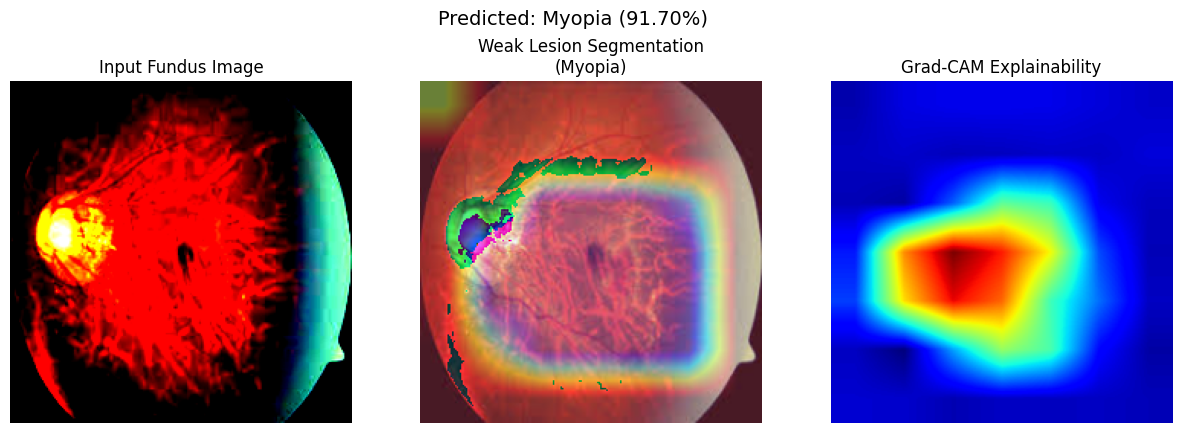

In [26]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Input Fundus Image")
plt.imshow(img.permute(1,2,0))
plt.axis("off")

plt.subplot(1,3,2)
plt.title(f"Weak Lesion Segmentation\n({disease})")
plt.imshow(attn_overlay)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Grad-CAM Explainability")
plt.imshow(gradcam_map, cmap="jet")
plt.axis("off")

plt.suptitle(f"Predicted: {disease} ({confidence:.2f}%)", fontsize=14)
plt.show()


## Model Serialization for Future Use

This cell saves:
- Trained model weights
- Class mappings
- Configuration parameters

Saving these components allows:
- Reuse without retraining
- Deployment
- Reproducibility
- Extension in future project phases


In [33]:
SAVE_DIR = "/kaggle/working/Trained Model"
os.makedirs(SAVE_DIR, exist_ok=True)

In [34]:
model_save_path = os.path.join(SAVE_DIR, "efficientnet_attention.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "num_classes": NUM_CLASSES,
    "class_to_idx": original_dataset.class_to_idx,
    "img_size": IMG_SIZE
}, model_save_path)

print(f"✅ Model saved at: {model_save_path}")

✅ Model saved at: /kaggle/working/Trained Model/efficientnet_attention.pth


In [35]:
class EfficientNetAttention(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        backbone = models.efficientnet_v2_s(pretrained=False)
        self.features = backbone.features

        self.attention = nn.Sequential(
            nn.Conv2d(1280, 256, 1),
            nn.ReLU(),
            nn.Conv2d(256, 1, 1),
            nn.Sigmoid()
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        feat = self.features(x)
        attn = self.attention(feat)
        feat = feat * attn
        pooled = self.pool(feat).flatten(1)
        out = self.classifier(pooled)
        return out, attn
        

checkpoint = torch.load(
    "/kaggle/working/Trained Model/efficientnet_attention.pth",
    map_location=DEVICE
)

model = EfficientNetAttention(checkpoint["num_classes"]).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

idx_to_class = {v: k for k, v in checkpoint["class_to_idx"].items()}
IMG_SIZE = checkpoint["img_size"]

print("✅ Model loaded successfully")
print("Classes:", idx_to_class)

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [39]:
IMAGE_PATH = "/kaggle/input/testingdataset/Mypio.jpg"   # <-- YOUR IMAGE PATH HERE

img = load_image_from_path(IMAGE_PATH)

# Predict
disease, confidence, attn_map, class_id = predict_disease(model, img)

print(f"\n🩺 Predicted Disease : {disease}")
print(f"📊 Confidence       : {confidence:.2f}%")

attn_overlay = get_attention_overlay(img, attn_map)

gradcam_map = generate_gradcam(img.to(DEVICE), class_id)



🩺 Predicted Disease : Myopia
📊 Confidence       : 91.70%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.4285715].


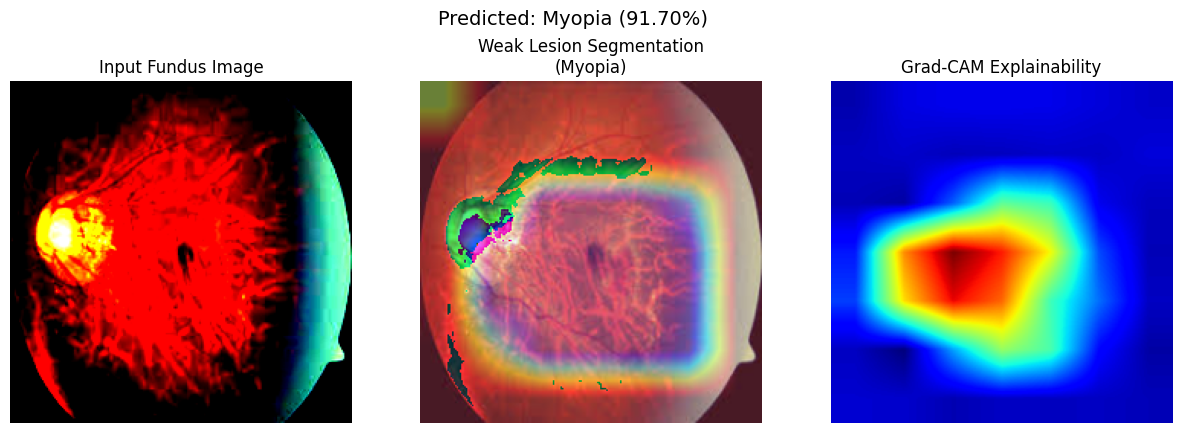

In [40]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Input Fundus Image")
plt.imshow(img.permute(1,2,0))
plt.axis("off")

plt.subplot(1,3,2)
plt.title(f"Weak Lesion Segmentation\n({disease})")
plt.imshow(attn_overlay)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Grad-CAM Explainability")
plt.imshow(gradcam_map, cmap="jet")
plt.axis("off")

plt.suptitle(f"Predicted: {disease} ({confidence:.2f}%)", fontsize=14)
plt.show()


## 📊 Dataset Statistics (Image Count)

This cell computes and displays:
- Number of images per disease class
- Total number of images in the Original dataset
- Total number of images in the Augmented dataset
- Combined total number of images

This helps understand class distribution and dataset scale.


In [41]:
from collections import Counter

def count_images(dataset):
    labels = [label for _, label in dataset.samples]
    return Counter(labels)

# Count images per class
original_counts = count_images(original_dataset)
augmented_counts = count_images(augmented_dataset)

print("📂 Original Dataset Image Count:")
total_original = 0
for idx, class_name in enumerate(class_names):
    count = original_counts[idx]
    total_original += count
    print(f"{class_name}: {count}")

print(f"\nTotal Original Images: {total_original}")

print("\n📂 Augmented Dataset Image Count:")
total_augmented = 0
for idx, class_name in enumerate(class_names):
    count = augmented_counts[idx]
    total_augmented += count
    print(f"{class_name}: {count}")

print(f"\nTotal Augmented Images: {total_augmented}")

print("\n📊 Combined Dataset Summary:")
print(f"Total Images (Original + Augmented): {total_original + total_augmented}")

📂 Original Dataset Image Count:
Central Serous Chorioretinopathy: 101
Diabetic Retinopathy: 1509
Disc Edema: 127
Glaucoma: 1349
Healthy: 1024
Macular Scar: 444
Myopia: 500
Pterygium: 17
Retinal Detachment: 125
Retinitis Pigmentosa: 139

Total Original Images: 5335

📂 Augmented Dataset Image Count:
Central Serous Chorioretinopathy: 606
Diabetic Retinopathy: 3444
Disc Edema: 762
Glaucoma: 2880
Healthy: 2676
Macular Scar: 1937
Myopia: 2251
Pterygium: 102
Retinal Detachment: 750
Retinitis Pigmentosa: 834

Total Augmented Images: 16242

📊 Combined Dataset Summary:
Total Images (Original + Augmented): 21577


## 📉 Confusion Matrix Visualization

This cell visualizes the confusion matrix as a heatmap image.

The visual representation makes it easier to:
- Identify misclassifications
- Analyze class-wise performance
- Present results in reports and publications


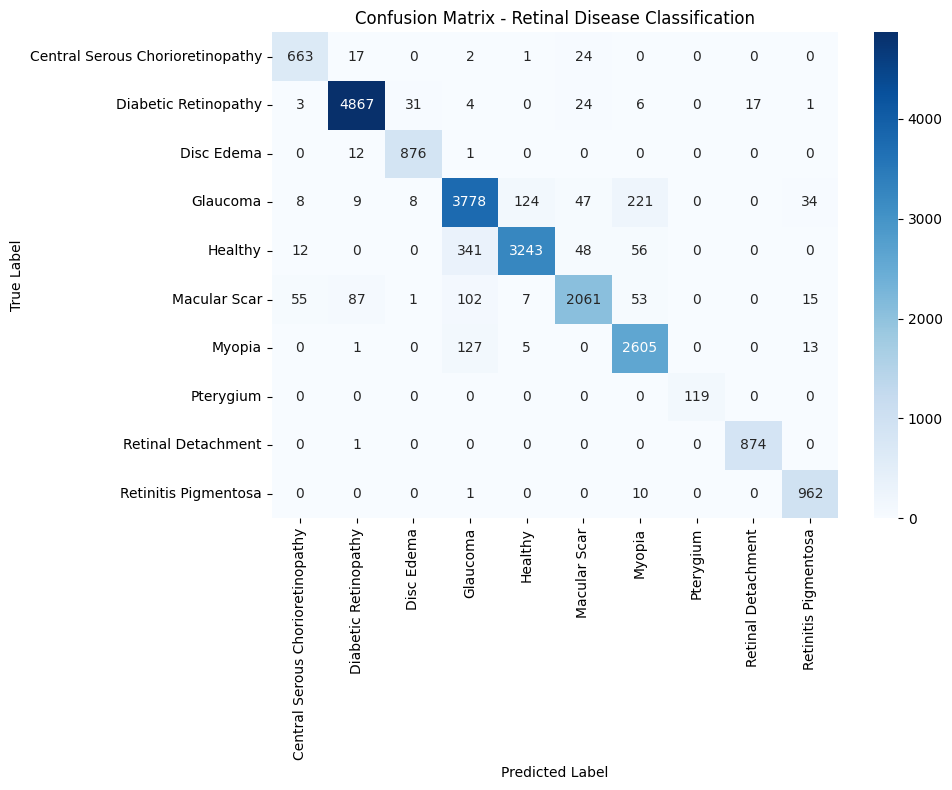

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Retinal Disease Classification")
plt.tight_layout()
plt.show()


In [43]:
print("\n📊 Class-wise Accuracy:")
for i, class_name in enumerate(class_names):
    class_correct = cm[i, i]
    class_total = cm[i].sum()
    acc = class_correct / class_total if class_total > 0 else 0
    print(f"{class_name}: {acc:.2%}")



📊 Class-wise Accuracy:
Central Serous Chorioretinopathy: 93.78%
Diabetic Retinopathy: 98.26%
Disc Edema: 98.54%
Glaucoma: 89.34%
Healthy: 87.65%
Macular Scar: 86.56%
Myopia: 94.69%
Pterygium: 100.00%
Retinal Detachment: 99.89%
Retinitis Pigmentosa: 98.87%
